# 13장 실습 — 지연 예산 분해

4부까지는 제어 지연을 **주기 수** 하나로 다뤘다. 배포 조건의 「지연 1주기」가 그것이다. 이 노트북은 그 한 주기 안을 연다. 관측에서 명령까지를 여섯 구간으로 나눠 구간마다 시간을 재고, 한 주기(50 ms) 예산에 들어가는지 본다.

| 구간 | 하는 일 | 이 노트북에서 |
|---|---|---|
| 영상 전처리 | 카메라 영상을 줄이고 정규화 | 480×640 영상을 해상도 r 로 |
| 인식 | 영상에서 부품·밀대 위치를 뽑는다 | ViT-Tiny 급 인코더 (무작위 가중치) |
| 상태 정규화 | 관측 벡터를 만들고 4장의 통계로 정규화 | `nz(env.obs())` |
| 정책 | 행동을 낸다 | 7장의 행동 복제 |
| 후처리 | 자르고 속도 단위로 바꾼다 | `clip × AMAX` |
| 명령 | 구동기에 쓴다 | `d.ctrl` 에 쓴다 |

인식 인코더는 학습하지 않았다. 이 책의 시뮬레이터는 위치를 바로 주므로 인식의 정확도는 재지 않고, **시간만** 잰다. 엣지 컴퓨터의 작은 계산 자원을 흉내 내려 파이토치의 연산 스레드를 하나로 묶는다(코어를 지정하지는 않는다).

그다음 잰 시간을 **지연 주기 수**로 바꿔 배포 조건에서 정책을 돌린다. 계산이 한 주기를 넘으면 명령이 한 주기 더 늦는다. 12장에서 행동 복제는 지연 2주기에서 0.698로 떨어졌다.

끝에서 `runtime/budget.json` 을 남긴다. 실행 시간은 CPU에서 6분 안팎이다. 잰 시간은 실행하는 컴퓨터마다 다르다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
import copy

SIG = .22


def dart_eps(count, seed, n=32, cond=None, sig=SIG):
    """잡음 주입 시연을 판 단위로 모은다 (cond: 그 조건의 셀)"""
    rng = np.random.default_rng(seed)
    env = Pert(n, seed, **COND[cond]) if cond else Cell(n, seed)
    cur = [[] for _ in range(n)]
    out = []
    while len(out) < count:
        o = env.obs()
        lab = servo(env)
        act = np.clip(lab + rng.normal(0, sig, lab.shape), -1, 1)
        for i in range(n):
            cur[i].append((o[i], lab[i]))
        dn = env.step(act.astype(np.float32))[1]
        for i in np.flatnonzero(dn):
            out.append(cur[i])
            cur[i] = []
    out = out[:count]
    X = np.array([a for e in out for a, _ in e], np.float32)
    Y = np.array([b for e in out for _, b in e], np.float32)
    return X, Y, np.array([len(e) for e in out])


def load_cell(path="data/cell_v1"):
    """6장의 데이터셋을 읽는다 — 없으면 같은 설정으로 모은다"""
    f = f"{path}/data/chunk-000/file-000.parquet"
    if os.path.exists(f):
        import pyarrow.parquet as pq
        t = pq.read_table(f)
        flat = lambda c: np.asarray(t[c].combine_chunks().flatten())
        X = flat("observation.state").reshape(-1, 10)
        X = X.astype(np.float32)
        Y = flat("action").reshape(-1, 2).astype(np.float32)
        st = json.load(open(f"{path}/meta/stats.json"))
        st = st["observation.state"]
        print(f"{path} 를 읽었다 — {len(X):,} 스텝")
        return X, Y, st
    X, Y, _ = dart_eps(128, seed=1)
    z = X[:, :8] / 10.
    st = {"method": "평균·표준편차", "mean": z.mean(0).tolist(),
          "std": (z.std(0) + 1e-8).tolist()}
    print(f"{path} 가 없다 — 잡음 주입 시연 128판을 모았다")
    return X, Y, st


XS, YS, STATS = load_cell()
MU = np.array(STATS["mean"], np.float32) * 10.   # 셀 척도로
SD = np.array(STATS["std"], np.float32) * 10.


def nz(o):
    """4장의 정규화 — 위치·속도 여덟 차원만 평균·표준편차로"""
    o = o.copy()
    o[:, :8] = (o[:, :8] - MU) / SD
    return o.astype(np.float32)


def pol(net):
    """정규화한 관측으로 평균 행동을 낸다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(nz(env.obs()))).numpy()
    return f


def cycle(rows):
    """성공한 판의 주기 중앙값 (스텝)"""
    st = [r[6] for r in rows if r[4]]
    return float(np.median(st)) if st else float("nan")

data/cell_v1 를 읽었다 — 5,792 스텝


In [8]:
import threading

PERIOD = 50.                     # 제어 주기 (ms) — 20 Hz


class ViT(nn.Module):
    """인식 단계 — ViT-Tiny 급. 무작위 가중치로 시간만 잰다"""

    def __init__(self, res=224, p=16, d=192, depth=12, heads=3):
        super().__init__()
        self.pe = nn.Conv2d(3, d, p, p)
        self.pos = nn.Parameter(torch.zeros(1, (res // p) ** 2, d))
        lay = nn.TransformerEncoderLayer(
            d, heads, 4 * d, dropout=0., batch_first=True,
            norm_first=True)
        self.enc = nn.TransformerEncoder(lay, depth,
                                         enable_nested_tensor=False)
        self.head = nn.Linear(d, 4)     # 부품·밀대 위치

    def forward(self, x):
        z = self.pe(x).flatten(2).transpose(1, 2) + self.pos
        return self.head(self.enc(z).mean(1))


class Load:
    """배경 부하 — 다른 작업이 같은 코어를 나눠 쓰는 상황"""

    def __init__(self, k=2):
        self.k, self.stop = k, threading.Event()

    def _work(self):
        a = torch.randn(384, 384)
        while not self.stop.is_set():
            a = torch.tanh(a @ a * 1e-3)

    def __enter__(self):
        self.th = [threading.Thread(target=self._work, daemon=True)
                   for _ in range(self.k)]
        for t in self.th:
            t.start()
        time.sleep(.2)
        return self

    def __exit__(self, *a):
        self.stop.set()
        for t in self.th:
            t.join()


def pct(ms):
    ms = np.asarray(ms)
    return (float(np.percentile(ms, 50)),
            float(np.percentile(ms, 99)), float(ms.max()))


def to_delay(ms):
    """계산 시간 → 명령이 늦는 주기 수. 한 주기 안이면 1이다"""
    d = np.ceil(np.asarray(ms) / PERIOD)
    return np.maximum(1, d).astype(int)

In [9]:
def execute(act, H, cond, delays=1, mode="naive", n=100, reps=2,
            seed=999, tag=0, ver="rt"):
    """추론 워커가 하나인 실행기.

    act(env, idx) 가 (len(idx), H, 2) 행동 묶음을 낸다.
    delays — 정수면 고정 지연, 배열이면 잰 계산 시간(ms) 표본.
    mode — sync(멈춰 기다린다) / naive(도착하면 처음부터)
           / skip(늦은 만큼 앞을 버린다)
    """
    env = Pert(n, seed, **{**COND[cond], "lat": 0})
    rng = np.random.default_rng(seed + 1)
    fixed = np.isscalar(delays)
    buf = np.zeros((n, H, 2), np.float32)
    nxt = np.zeros((n, H, 2), np.float32)
    base = np.full(n, -10 ** 6)
    pend = np.full(n, -1)
    iss = np.zeros(n, int)
    dhat = np.ones(n, int)
    last = np.zeros((n, 2), np.float32)
    rows = []
    for t in range(EP * reps):
        arr = np.flatnonzero(pend == t)
        buf[arr] = nxt[arr]
        base[arr] = iss[arr] if mode == "skip" else t
        pend[arr] = -1
        k = t - base
        idle = pend < 0
        if mode == "sync":
            ask = idle & (k >= H)
        else:
            ask = idle & (k >= H - dhat)
        idx = np.flatnonzero(ask)
        if len(idx):
            nxt[idx] = act(env, idx)
            d = (np.full(len(idx), delays) if fixed else
                 to_delay(rng.choice(delays, len(idx))))
            iss[idx], pend[idx], dhat[idx] = t, t + d, d
        ok = (k >= 0) & (k < H)
        a = np.zeros((n, 2), np.float32) if mode == "sync" else last
        a = a.copy()
        a[ok] = buf[ok, k[ok]]
        last = a
        _, dn, sc = env.step(a)
        for hit, wrong, steps, kk in sc:
            rows.append((cond, ver, tag, "AB"[kk], hit, wrong,
                         steps))
        d = np.flatnonzero(dn)
        base[d], pend[d], last[d] = -10 ** 6, -1, 0.
    return rows


def step_act(net):
    """한 스텝 정책을 H=1 묶음으로 감싼다"""
    def f(env, idx):
        o = torch.from_numpy(nz(env.obs()[idx]))
        with torch.no_grad():
            return net.pi(o).numpy()[:, None, :]
    return f

## 정책과 측정 준비

7장의 행동 복제를 읽는다(없으면 같은 설정으로 학습한다). 파이토치 스레드를 하나로 묶는다.

In [10]:
import warnings
import torch.nn.functional as F
warnings.filterwarnings("ignore")
torch.set_num_threads(1)

BC = (torch.load("policy/bc_v1.pt", weights_only=False)
      if os.path.exists("policy/bc_v1.pt")
      else bc(nz(XS), YS, seed=0))
STAGES = ["영상 전처리", "인식", "상태 정규화", "정책", "후처리",
          "명령"]
FRAME = np.random.default_rng(0).integers(0, 256, (480, 640, 3),
                                          np.uint8)


def measure(res=224, N=300, quant=False):
    """한 주기를 N 번 돌며 구간마다 시간(ms)을 잰다"""
    vit = ViT(res).eval()
    if quant:
        vit = torch.ao.quantization.quantize_dynamic(
            vit, {nn.Linear}, dtype=torch.qint8)
    env = Pert(1, 0, **COND["배포"])
    d = env.d[0]
    T = np.zeros((N + 20, 6))
    with torch.no_grad():
        for i in range(N + 20):
            t0 = time.perf_counter()
            x = torch.from_numpy(FRAME).permute(2, 0, 1)[None]
            x = F.interpolate(x.float() / 255., size=(res, res),
                              mode="bilinear", align_corners=False)
            x = (x - .45) / .25
            t1 = time.perf_counter()
            vit(x)
            t2 = time.perf_counter()
            o = torch.from_numpy(nz(env.obs()))
            t3 = time.perf_counter()
            a = BC.pi(o).numpy()
            t4 = time.perf_counter()
            u = np.clip(a[0], -1, 1) * AMAX
            t5 = time.perf_counter()
            d.ctrl[:] = u
            t6 = time.perf_counter()
            T[i] = np.diff([t0, t1, t2, t3, t4, t5, t6])
    return T[20:] * 1e3          # 앞의 20번은 예열이다


t0 = time.time()
T224 = measure(224)
print(f"측정 끝 ({time.time() - t0:.0f}s)")

측정 끝 (11s)


## 구간별 예산표

해상도 224, 부하 없음. 한 주기 50 ms 가운데 각 구간이 차지하는 몫을 적는다.

In [11]:
def table(T):
    tot = T.sum(1)
    print(pad("구간", 14) + pad("p50", 9, True)
          + pad("p99", 9, True) + pad("최대", 9, True)
          + pad("p50 몫", 10, True))
    for j, s in enumerate(STAGES):
        p = pct(T[:, j])
        print(pad(s, 14) + "".join(pad(f"{v:.3f}", 9, True)
                                   for v in p)
              + pad(f"{p[0] / np.median(tot):.1%}", 10, True))
    p = pct(tot)
    print(pad("합계", 14) + "".join(pad(f"{v:.3f}", 9, True)
                                   for v in p))
    miss = (tot > PERIOD).mean()
    print(f"\n예산 {PERIOD:.0f} ms 를 넘긴 주기: {miss:.1%}"
          f"  (p50 합계가 예산의 {p[0] / PERIOD:.0%})")


table(T224)

구간                p50      p99     최대    p50 몫
영상 전처리       1.449    1.970    3.556      4.3%
인식             32.086   40.375   41.844     94.9%
상태 정규화       0.105    0.188    0.208      0.3%
정책              0.074    0.162    0.170      0.2%
후처리            0.023    0.070    0.100      0.1%
명령              0.003    0.005    0.012      0.0%
합계             33.799   42.525   44.040

예산 50 ms 를 넘긴 주기: 0.0%  (p50 합계가 예산의 68%)


## 해상도와 배경 부하

인식이 예산을 지배한다면 해상도가 손잡이다. 그리고 실기의 엣지 컴퓨터는 정책만 돌리지 않는다. 로깅, 시각화, 다른 센서 처리가 같은 코어를 나눠 쓴다. 배경 스레드 둘로 그 상황을 흉내 낸다.

In [12]:
RES = [96, 128, 160, 224]
TOT = {}
t0 = time.time()
for load in (0, 2):
    for r in RES:
        if load:
            with Load(load):
                T = measure(r)
        else:
            T = T224 if r == 224 else measure(r)
        TOT[(r, load)] = T.sum(1)
    print(f"  부하 {load} 끝 ({time.time() - t0:.0f}s)", flush=True)

print()
print(pad("해상도", 8) + pad("부하", 6) + pad("p50", 9, True)
      + pad("p99", 9, True) + pad("최대", 9, True)
      + pad("예산 초과", 11, True) + pad("3주기 이상", 12, True))
for (r, load), tot in TOT.items():
    p = pct(tot)
    print(pad(r, 8) + pad("있음" if load else "없음", 6)
          + "".join(pad(f"{v:.1f}", 9, True) for v in p)
          + pad(f"{(tot > PERIOD).mean():.1%}", 11, True)
          + pad(f"{(to_delay(tot) >= 3).mean():.1%}", 12, True))

  부하 0 끝 (13s)


  부하 2 끝 (54s)



해상도  부하        p50      p99     최대  예산 초과  3주기 이상
96      없음       10.5     14.4     18.6       0.0%        0.0%
128     없음       14.0     20.0     20.7       0.0%        0.0%
160     없음       16.2     21.8     25.4       0.0%        0.0%
224     없음       33.8     42.5     44.0       0.0%        0.0%
96      있음       20.4     43.0     50.7       0.3%        0.0%
128     있음       19.4     54.2     67.7       2.3%        0.0%
160     있음       29.2     51.2     57.3       1.3%        0.0%
224     있음       45.4     88.7     99.5      42.0%        0.0%


## 잰 시간을 지연으로 바꿔 돌린다

추론 워커는 하나다. 워커는 관측을 받아 계산하고, 계산이 끝난 주기의 다음 주기에 명령이 나간다. 계산이 한 주기 안이면 지연 1주기(배포 조건 그대로), 두 주기에 걸치면 2주기다. 워커가 바쁜 동안에는 새 관측을 받지 않고, 구동기는 마지막 명령을 유지한다.

잰 계산 시간 표본에서 요청마다 하나를 뽑아 지연을 정한다. 기준으로 고정 지연 1·2주기도 함께 돌린다.

In [13]:
RUNS = {"고정 1주기": 1, "고정 2주기": 2,
        "224 · 부하 없음": TOT[(224, 0)],
        "224 · 부하": TOT[(224, 2)],
        "160 · 부하": TOT[(160, 2)],
        "128 · 부하": TOT[(128, 2)]}
LOG, CL = [], {}
t0 = time.time()
for name, dl in RUNS.items():
    rs = []
    for s in range(3):
        rows = execute(step_act(BC), 1, "배포", delays=dl,
                       seed=999 + s, tag=s, ver=f"budget-{name}",
                       n=100, reps=2)
        LOG.extend(rows)
        rs.append(rate(rows))
    CL[name] = rs
    print(pad(name, 18) + f"{np.mean(rs):.3f}  "
          f"[{min(rs):.2f}, {max(rs):.2f}]", flush=True)
print(f"({time.time() - t0:.0f}s)")

고정 1주기        0.969  [0.96, 0.97]


고정 2주기        0.441  [0.43, 0.46]


224 · 부하 없음   0.969  [0.96, 0.97]


224 · 부하        0.910  [0.90, 0.93]


160 · 부하        0.969  [0.96, 0.98]


128 · 부하        0.972  [0.97, 0.98]


(51s)


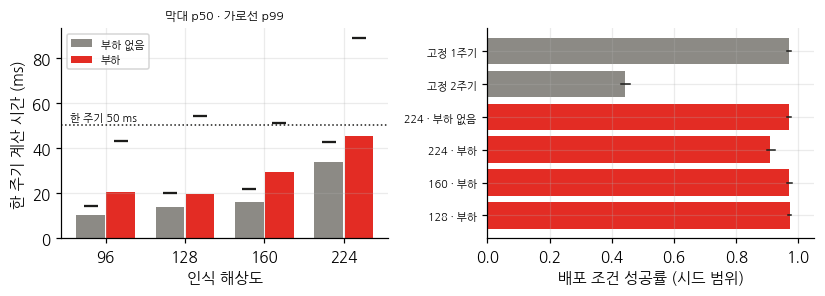

In [14]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.6, 2.8))
x = np.arange(len(RES))
for j, (load, col, lab) in enumerate(((0, GREY, "부하 없음"),
                                      (2, RED, "부하"))):
    p50 = [np.median(TOT[(r, load)]) for r in RES]
    p99 = [np.percentile(TOT[(r, load)], 99) for r in RES]
    a1.bar(x + (j - .5) * .38, p50, .36, color=col, label=lab)
    a1.scatter(x + (j - .5) * .38, p99, color=INK, marker="_", s=90,
               zorder=3)
a1.axhline(PERIOD, color=INK, ls=":", lw=1)
a1.text(-.45, PERIOD + 2, "한 주기 50 ms", fontsize=7)
a1.set_xticks(x, [str(r) for r in RES])
a1.set_xlabel("인식 해상도")
a1.set_ylabel("한 주기 계산 시간 (ms)")
a1.legend(fontsize=7, loc="upper left")
a1.set_title("막대 p50 · 가로선 p99", fontsize=8)
names = list(RUNS)
m = [np.mean(CL[k]) for k in names]
a2.barh(range(len(names)), m,
        color=[GREY if "고정" in k else RED for k in names])
for i, k in enumerate(names):
    a2.plot([min(CL[k]), max(CL[k])], [i, i], color=INK, lw=1)
a2.set_yticks(range(len(names)), names, fontsize=7)
a2.invert_yaxis()
a2.set_xlim(0, 1.05)
a2.set_xlabel("배포 조건 성공률 (시드 범위)")
plt.tight_layout()
plt.show()

## 예산표를 남긴다

In [15]:
os.makedirs("runtime", exist_ok=True)
out = {"period_ms": PERIOD,
       "stages_224": {s: dict(zip(("p50", "p99", "max"),
                                  [round(v, 4) for v in
                                   pct(T224[:, j])]))
                      for j, s in enumerate(STAGES)},
       "configs": {f"{r}-{'load' if l else 'idle'}":
                   {"p50": round(pct(t)[0], 2),
                    "p99": round(pct(t)[1], 2),
                    "miss": round(float((t > PERIOD).mean()), 4)}
                   for (r, l), t in TOT.items()},
       "closed_loop": {k: round(float(np.mean(v)), 3)
                       for k, v in CL.items()},
       "samples_224_load": np.round(TOT[(224, 2)], 2).tolist(),
       "samples_224_idle": np.round(TOT[(224, 0)], 2).tolist()}
with open("runtime/budget.json", "w") as f:
    json.dump(out, f, ensure_ascii=False, indent=1)
save_log("report/ch13_log.csv", LOG)
print("runtime/budget.json 저장")
print(f"report/ch13_log.csv  판별 로그 {len(LOG):,}줄")

runtime/budget.json 저장
report/ch13_log.csv  판별 로그 6,251줄
